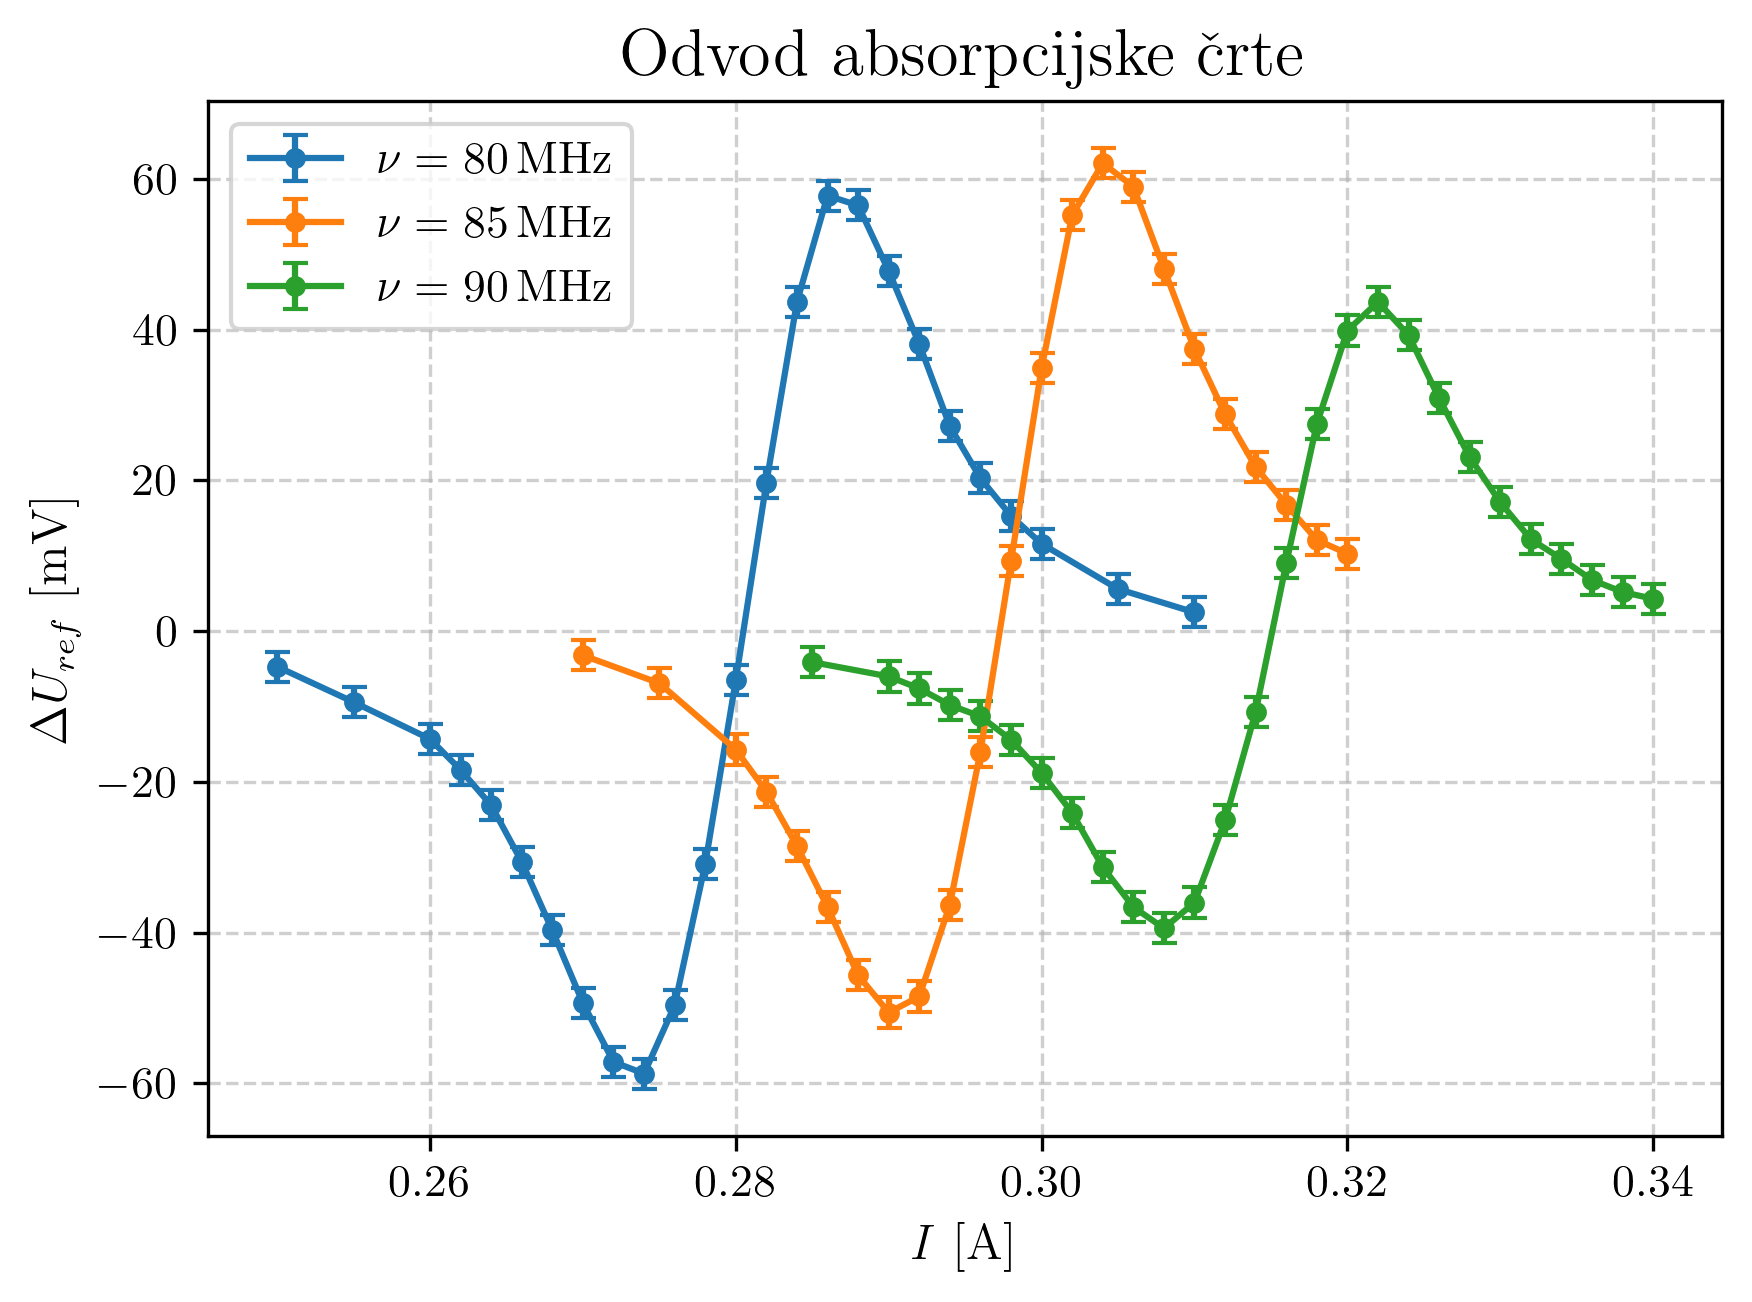

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Nastavitve za LaTeX prijazen izris
plt.rcParams.update({
    "text.usetex": True,              # omogoči LaTeX slog besedila
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# --- Podatki pri 80 MHz ---
I_80 = np.array([0.25, 0.255, 0.26, 0.262, 0.264, 0.266, 0.268, 0.27, 0.272, 0.274,
                 0.276, 0.278, 0.28, 0.282, 0.284, 0.286, 0.288, 0.29, 0.292, 0.294,
                 0.296, 0.298, 0.3, 0.305, 0.31])
U_80 = np.array([49.3, 44.6, 39.7, 35.6, 30.9, 23.4, 14.3, 4.66, -3.15, -4.71,
                 4.35, 23.1, 47.5, 73.7, 97.7, 111.8, 110.5, 101.8, 92.1, 81.2,
                 74.3, 69.3, 65.6, 59.6, 56.5])

# --- Podatki pri 85 MHz ---
I_85 = np.array([0.27, 0.275, 0.28, 0.282, 0.284, 0.286, 0.288, 0.29, 0.292, 0.294,
                 0.296, 0.298, 0.3, 0.302, 0.304, 0.306, 0.308, 0.31, 0.312, 0.314,
                 0.316, 0.318, 0.32])
U_85 = np.array([46.8, 43.1, 34.3, 28.7, 21.5, 13.4, 4.35, -0.6, 1.53, 13.7,
                 34, 59.3, 84.9, 105.2, 112.1, 109, 98.1, 87.4, 78.8, 71.8,
                 66.8, 62.1, 60.3])

# --- Podatki pri 90 MHz ---
I_90 = np.array([0.285, 0.29, 0.292, 0.294, 0.296, 0.298, 0.3, 0.302, 0.304, 0.306,
                 0.308, 0.31, 0.312, 0.314, 0.316, 0.318, 0.32, 0.322, 0.324, 0.326,
                 0.328, 0.33, 0.332, 0.334, 0.336, 0.338, 0.34])
U_90 = np.array([43.9, 42, 40.4, 38.2, 36.7, 33.6, 29.2, 23.9, 16.7, 11.4,
                 8.59, 12, 22.9, 37.3, 57, 75.5, 87.9, 91.7, 87.3, 78.9,
                 71.1, 65.1, 60.2, 57.6, 54.8, 53.2, 52.3])

U_error=2

# --- Risanje grafa ---
plt.figure(figsize=(6, 4.5))
plt.errorbar(I_80, U_80-54, yerr=U_error, fmt='o-', ms=4, capsize=3, label=r'$\nu = 80\,\mathrm{MHz}$')
plt.errorbar(I_85, U_85-50, yerr=U_error, fmt='o-', ms=4, capsize=3, label=r'$\nu = 85\,\mathrm{MHz}$')
plt.errorbar(I_90, U_90-48, yerr=U_error, fmt='o-', ms=4, capsize=3, label=r'$\nu = 90\,\mathrm{MHz}$')
#plt.errorbar(np.array([0.2805,0.29725,0.3151]),np.array([0,0,0]), ms=1, fmt='o')


plt.title(r'Odvod absorpcijske črte')
plt.xlabel(r'$I$ [A]')
plt.ylabel(r'$\Delta U_{ref}$ [mV]')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Shrani kot PDF za LaTeX
plt.savefig("graf_frekvence.pdf", bbox_inches='tight')

plt.show()


0.0034600000000000117 0.0035166666666657767


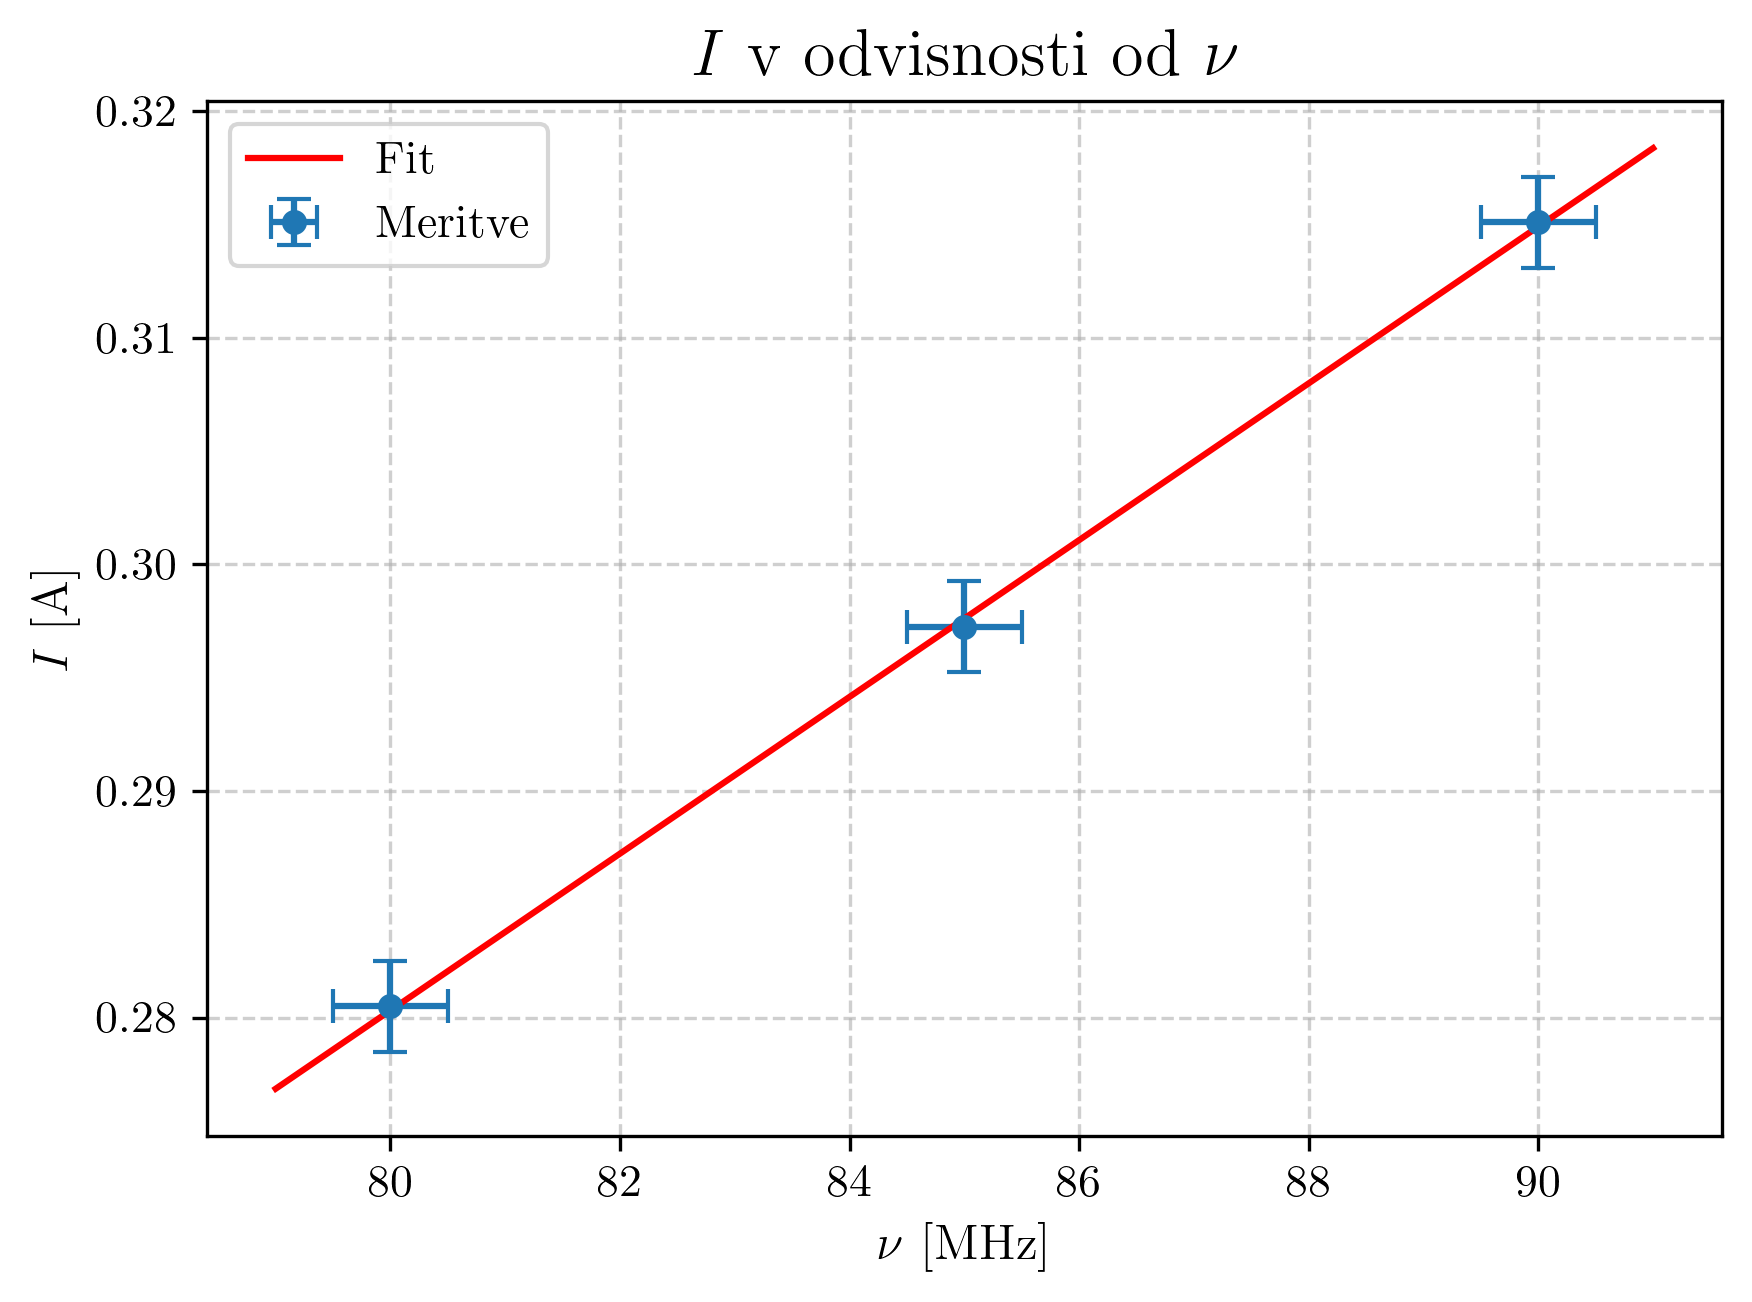

In [54]:
f = np.array([80, 85, 90])          # frekvenca [MHz]
I = np.array([0.2805, 0.29725, 0.3151]) 

coeffs = np.polyfit(f, I, 1)
a, b = coeffs
print(a,b)
fit_line = np.poly1d(coeffs)

# Generiraj točke za fit
f_fit = np.linspace(min(f)-1, max(f)+1, 100)
I_fit = fit_line(f_fit)

f_err = 0.5     # [MHz]
I_err = 0.002

plt.figure(figsize=(6, 4.5))
plt.errorbar(f, I, xerr=f_err, yerr=I_err, fmt='o', ms=5, capsize=4, label=r'Meritve')
plt.plot(f_fit, I_fit, '-', color='red', label=rf'Fit')


plt.title(r'$I$ v odvisnosti od $\nu$')
plt.xlabel(r'$\nu$ [MHz]')
plt.ylabel(r'$I$ [A]')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Shrani kot PDF za LaTeX
plt.savefig("graf_b(f).pdf", bbox_inches='tight')

plt.show()